In [1]:
import sys
import os
# change the path to your own path, make sure unzip data.zip at same place
sys.path.append("/Users/wangweixiang/Downloads/Link_Prediction_metric_consider_structure_result 2")
current_path = os.getcwd()
# change the path to your own path, make sure unzip data.zip at same place
os.chdir("/Users/wangweixiang/Downloads/Link_Prediction_metric_consider_structure_result 2")
from utils.parameter_parser import parameter_parser
from utils.utils import tab_printer, read_data,  walk_exist
from utils.eval import get_accuracy_scores, get_modularity, get_information_unfairness, get_Gini_coefficient
from algs.proximity_base import jaccard, adamic_adar, preferential_attachment
from algs.greedy import greedy_wrapper
from skipGram.walk_generator import walk_generator
from algs.flip import DW_GAN_LP
from utils.logger import Logger
from algs.mab import MAB_LP

from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split

import pandas as pd
from numpy import trapz

import csv
%config InlineBackend.figure_format = 'svg'

args = parameter_parser()
# change the data name
args.file_name = "bowdoin.pk"
tab_printer(args)
data = read_data(args)
logger = Logger(args)
train, test = train_test_split(data['examples'], test_size=args.test_size, random_state=1)
print(train)
G = data['G']

G_original = data['G'].copy()
communities = data['communities']
for i in range(len(communities)):
        for node in communities[i]:
            G_original.nodes[node]['att'] = i

# build positive edges G (oracle) based on data['example']
G_oracle = G.copy()
positive_edges = [[e[0], e[1]] for e in data['examples'] if e[2] == 1]
G_oracle.add_edges_from(positive_edges)

# Run basline
if args.algorithm == "jac":
    y_pred_test = jaccard(G, test)
    y_pred_train = jaccard(G, train)
elif args.algorithm == "adar":
    y_pred_test = adamic_adar(G, test)
    y_pred_train = adamic_adar(G, train)
elif args.algorithm == "prf":
    y_pred_test = preferential_attachment(G, test)
    y_pred_train = preferential_attachment(G, train)

# calculate accurcay and modred of baseline
acc , roc_auc, _ = get_accuracy_scores(test , y_pred_test, median = np.median(y_pred_test))
print('baseline acc:', np.round(acc,4))
print('baseline auc:', np.round(roc_auc,4))

baselin_acc = acc

os.chdir(current_path)

/Users/wangweixiang/opt/anaconda3/envs/stratified-disparity/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


+-----------------+----------------+
|    Parameter    |     Value      |
+=================+================+
| Algorithm       | jac            |
+-----------------+----------------+
| Batch size      | 32             |
+-----------------+----------------+
| Beta d          | 0.100          |
+-----------------+----------------+
| Beta g          | 0.900          |
+-----------------+----------------+
| Beta l          | 0.200          |
+-----------------+----------------+
| Change percent  | 0.030          |
+-----------------+----------------+
| Cuda            | 0              |
+-----------------+----------------+
| Dimensions      | 128            |
+-----------------+----------------+
| Embedding path  | ./data/embds/  |
+-----------------+----------------+
| Epochs          | 3              |
+-----------------+----------------+
| File            | None           |
+-----------------+----------------+
| File name       | bowdoin.pk     |
+-----------------+----------------+
|

In [2]:
c = 0
num_candidate_edges=[]
valid_nodes = []
acc_list = []
for n in G.nodes:
    
    # candidate edges is the all non-exist 2-hop nodes, average number is 89, min is 1
    candidate_nodes = []
    for neighbor in list(G.adj[n]):
        candidate_nodes += [i_ for i_ in G.adj[neighbor] if i_ != n]
    
    '''
    # candidate edges is the all non-exist 3-hop nodes, average number is 543, min is 3
    candidate_nodes = []
    two_hops = []
    for neighbor in list(G.adj[n]):
        two_hops += [i_ for i_ in G.adj[neighbor] if i_ != n]
    for t_h in two_hops:
        for neighbor in list(G.adj[t_h]):
            candidate_nodes += [i_ for i_ in G.adj[neighbor] if i_ != n]
    '''
  
    # avoid add one edge multiple times
    candidate_edges = set()
    for cn in candidate_nodes:
        if cn not in G.adj[n]:
            candidate_edges.add((n, cn))
    
    candidate_edges_array = []
    for item in candidate_edges:
        candidate_edges_array.append([item[0], item[1], 0])
        
    candidate_edges_array = np.array(candidate_edges_array)
    
    c+=len(candidate_edges)
    num_candidate_edges.append(len(candidate_edges))
            
    # for each nodes recommend at least 10 edges
    num_recommend = 10
    if len(candidate_edges_array) == 0:
        print("no candidate")
        continue # make sure all node at least has one candidate
    y_pred = jaccard(G, candidate_edges_array)
    valid_nodes.append(n)
    
    score = []
    for i, x in enumerate(y_pred):
        score.append([candidate_edges_array[i][0], candidate_edges_array[i][1], x])
    score.sort(key=lambda x: x[2], reverse=True)
    
    # compute accuracy
    number_predict =  min(num_recommend, len(score))
    number_correct = 0
    acc = -1
    for i in range(number_predict):
        # correct
        if score[i][0] in G_oracle.adj[score[i][1]]:
            number_correct += 1
    if len(score) != 0: # 重复的工作，上面的continue 保证这里一定是有至少一个candidate
        acc = number_correct/ number_predict
    else:
        print("ERROR: no candidate node is found")

    acc_list.append(acc)

print(c/G_original.number_of_nodes())
print(min(num_candidate_edges))

no candidate
no candidate
773.8259325044405
0


<Axes: title={'center': 'Stratified Disparity Curve'}, xlabel='Number of bins', ylabel='Stratified Disparity'>

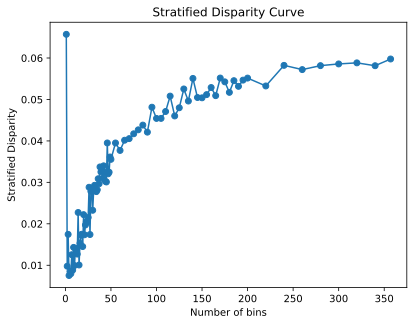

In [3]:
import networkx as nx
from stratified_disparity import StratifiedDisparity

def bin_by_degree(G, valid_nodes):
    return [G.degree(n) for n in valid_nodes]

def std(acc):
    return np.std(acc, ddof=1)
    
SD = StratifiedDisparity(G_original, valid_nodes, bin_by_degree, std, data_log=False)
curve = SD.compute_curve(acc_list, 'att')
SD.plot_curve(curve)

<Axes: xlabel='Structure bin', ylabel='Average performance'>

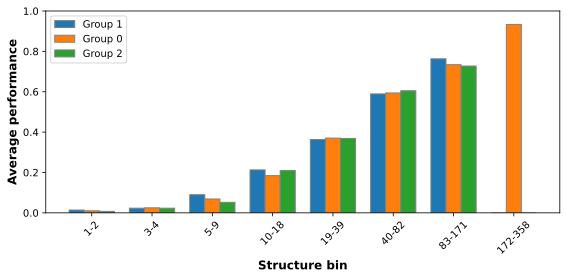

In [4]:
SD.plot_bin_group_performance(acc_list=acc_list, group_labels='att', num_bin=8)

<Axes: title={'center': 'Stratified Disparity Curve'}, xlabel='Number of bins', ylabel='Stratified Disparity'>

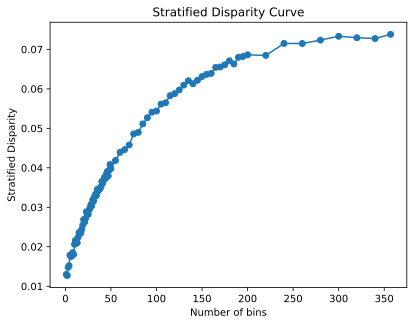

In [6]:
baseline = SD.permutation_baseline(
    acc_list=acc_list,
    group_labels='att',
    n_perm=20,
    random_state=42,
)
SD.plot_curve(baseline)

{'num_bins': 15.0, 'stratified_disparity': -0.013534380889777915}


<Axes: title={'center': 'Stratified Disparity Curve'}, xlabel='Number of bins', ylabel='Stratified Disparity'>

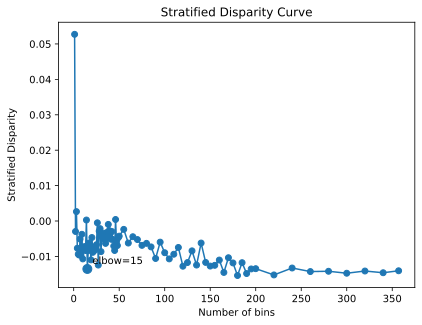

In [12]:
denoised_curve = curve.copy()
denoised_curve["stratified_disparity"] = (
    curve["stratified_disparity"]
    - baseline["stratified_disparity"]
)
elbow = SD.find_elbow(denoised_curve)
print(elbow)
SD.plot_curve(denoised_curve, elbow=elbow)